In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_excel("/content/placement_predict_50k Dataset_final.xlsx")
target_col = "CGPA"
drop_cols = [target_col, "StudentID", "CGPA_Tier"]
feature_df = df.drop(columns=drop_cols).select_dtypes(include=[np.number])
feature_df = feature_df.fillna(feature_df.median())
X = feature_df.values
y = df[target_col].values.reshape(-1, 1)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

In [6]:
def gradient_descent(X, y, lr=0.01, n_iters=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []
    for i in range(n_iters):
        y_pred = X @ theta
        error = y_pred - y
        loss = (1 / (2 * m)) * np.sum(error ** 2)
        losses.append(loss)
        gradient = (1 / m) * (X.T @ error)
        theta -= lr * gradient
        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss: {loss:.4f}")
    return theta, losses
theta, losses = gradient_descent(X_train_b, y_train, lr=0.01, n_iters=1000)

Iteration    0 | Loss: 27.5449
Iteration  100 | Loss: 3.6438
Iteration  200 | Loss: 0.5800
Iteration  300 | Loss: 0.1654
Iteration  400 | Loss: 0.1082
Iteration  500 | Loss: 0.0998
Iteration  600 | Loss: 0.0983
Iteration  700 | Loss: 0.0979
Iteration  800 | Loss: 0.0977
Iteration  900 | Loss: 0.0976


In [7]:
y_pred = X_test_b @ theta
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nFinal weights (theta):")
print(theta.ravel())
print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")

from sklearn.linear_model import LinearRegression
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)
sk_mse = mean_squared_error(y_test, sk_pred)
print(f"Sklearn Test MSE: {sk_mse:.4f}")


Final weights (theta):
[ 7.24382401  0.22136797  0.20714545  0.19391788  0.18710597  0.1703889
  0.15718881  0.15590153  0.14210222  0.04466781  0.07018233  0.09508345
 -0.09890673 -0.13948908 -0.06433497  0.21609615 -0.09399594  0.37238503
 -0.17019913 -0.02192028 -0.10237805 -0.03382736  0.06590428]

Test MSE : 0.2051
Test R^2 : 0.9212
Sklearn Test MSE: 0.2042



sklearn LinearRegression R^2: 0.9216

Saved plots to gradient_descent_plots.png


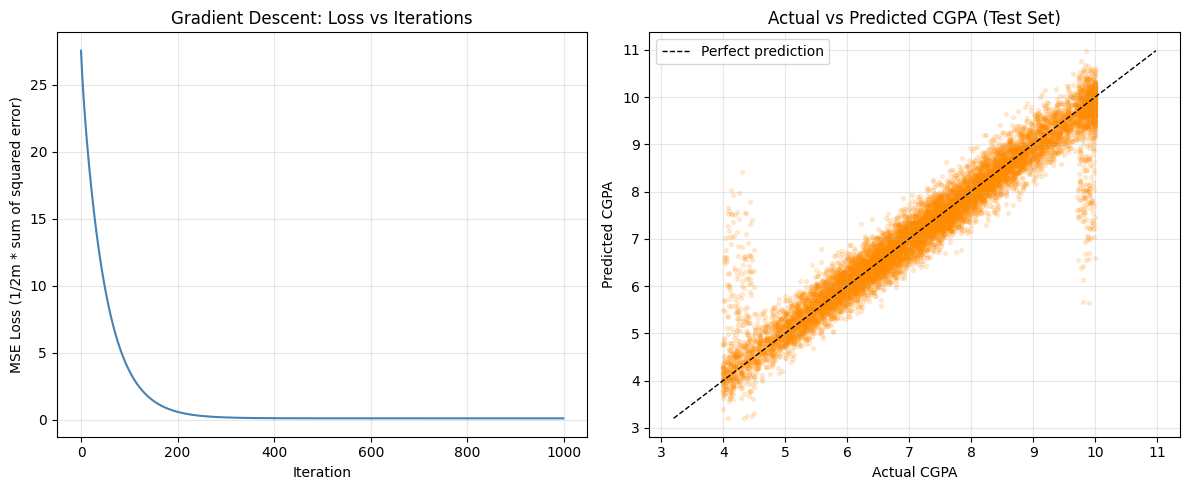

In [10]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

print(f"\nsklearn LinearRegression R^2: {r2_score(y_test, sk_pred):.4f}")

# 7. Plots

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Gradient descent loss curve
axes[0].plot(range(len(losses)), losses, color="steelblue")
axes[0].set_title("Gradient Descent: Loss vs Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE Loss (1/2m * sum of squared error)")
axes[0].grid(alpha=0.3)

# (b) Actual vs Predicted CGPA on the test set
axes[1].scatter(y_test, y_pred, alpha=0.15, s=8, color="darkorange")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, color="black", linestyle="--", linewidth=1, label="Perfect prediction")
axes[1].set_title("Actual vs Predicted CGPA (Test Set)")
axes[1].set_xlabel("Actual CGPA")
axes[1].set_ylabel("Predicted CGPA")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gradient_descent_plots.png", dpi=150)
print("\nSaved plots to gradient_descent_plots.png")
plt.show()